probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [3]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

# Load data
start_time = 0.0
end_time = 0.50
padding = 0.1
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=798911424,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 246, 268, 270, 284, 274, 249, 263, 261, 286, 258, 278, 267, 280, 256, 
                                          260, 257, 281],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

V1.get_lfp()
# V1.remove_padding(padding)
# V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


Downloading:   0%|          | 0.00/2.54G [00:00<?, ?B/s]

/home/qix/anaconda3/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


Text(0.5, 1.0, 'Distribution of mean running speed')

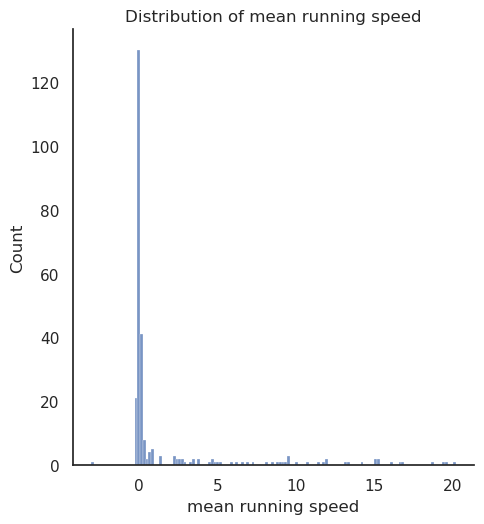

In [4]:
import seaborn as sns
sns.displot(V1.mean_speed)
plt.xlabel('mean running speed')
plt.title('Distribution of mean running speed')

## Time domain

In [5]:
### Get to know which channels are located in cortex
for probe in V1.selected_probes:
    print( V1.lfp[probe].structure_acronyms, V1.lfp[probe].intervals_lfp )

['APN' 'NOT' 'DG' 'CA1' 'VISam' nan] [ 0 10 18 28 47 71 82]
[nan] [ 0 79]
['DG' 'ProS' 'SUB' 'VISp' nan] [ 0 15 26 39 62 71]
['CA3' 'CA2' 'CA1' 'VISl' nan] [ 0  5  7 33 57 65]
['LGv' 'CA3' 'CA2' 'CA1' 'VISal' nan] [ 0 11 30 32 52 75 83]
['APN' 'TH' 'Eth' 'LP' 'DG' 'CA3' 'DG' 'CA1' 'VISrl' nan] [ 0  4  6  7 28 29 38 45 61 85 95]


In [7]:
cortex_channel = {'probeA':[47,71],
                  'probeB':[39,62], # Not sure
                  'probeC':[39,62],
                  'probeD':[33,57],
                  'probeE':[52,75],
                  'probeF':[61,85]}

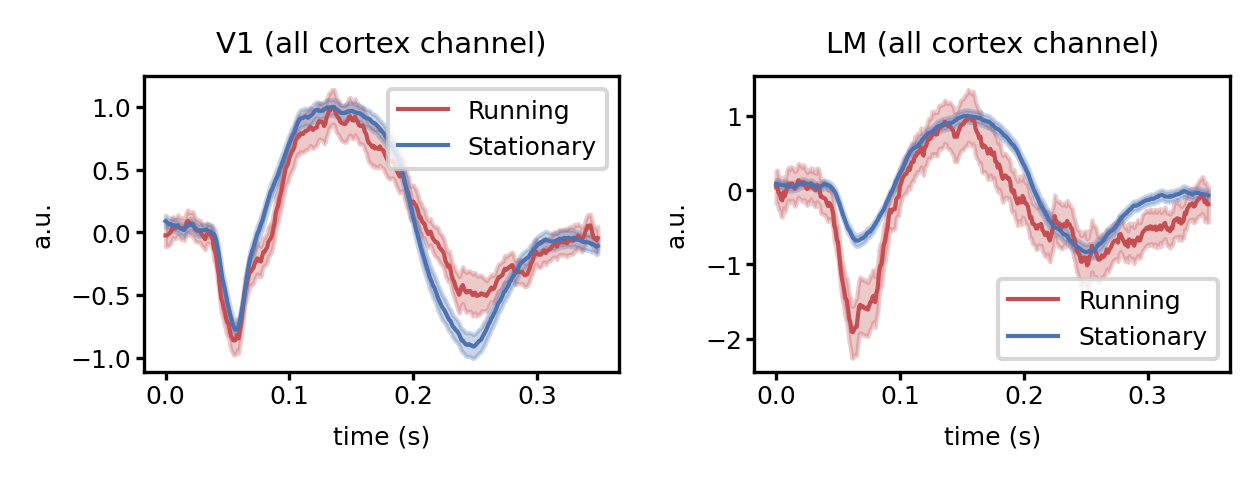

In [8]:
utils.use_pdf_plot()
fig, axs = plt.subplots(1, 2, figsize=(4.3, 1.7), dpi=300)
probes = ['probeC', 'probeD']

for i, probe in enumerate(probes):
    ax = axs[i]  # Select subplot
    
    # Assuming channel_id and other relevant variables are defined elsewhere
    channel_id = np.arange(cortex_channel[probe][0], cortex_channel[probe][1])
    
    data = V1.lfp[probe].lfp[:,:,V1.running_trial_index]
    start, end = 100, 450
    
    x = np.arange(0, 0.35, 1/1000)
    y = data[channel_id, start:end, :].mean(axis=(0,2))
    
    # Normalizing y
    y_max = y.max()
    y = y / y_max
    ci = data[channel_id, start:end, :].std(axis=(0,2)) / (y_max * np.sqrt(data.shape[2]))
    
    ax.plot(x, y, label='Running', color='r')
    ax.fill_between(x, (y-ci), (y+ci), color='r', alpha=.3)
    
    data = V1.lfp[probe].lfp[:,:,V1.stationary_trial_index]
    y = data[channel_id, start:end, :].mean(axis=(0,2))
    
    # Normalizing y
    y_max = y.max()
    y = y / y_max
    ci = data[channel_id, start:end, :].std(axis=(0,2)) / (y_max * np.sqrt(data.shape[2]))
    
    ax.plot(x, y, label='Stationary', color='b')
    ax.fill_between(x, (y-ci), (y+ci), color='b', alpha=.3)
    
    ax.legend()
    ax.set_title(f'{utils.PROBE_CORRESPONDING[probe]} (all cortex channel)')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('a.u.')  # Changing y-axis label to arbitrary units
    
plt.tight_layout()
# plt.savefig('Figures/SupFig/LFP.pdf', format='pdf', dpi=300)

# Granger Causality

In [9]:
import os, importlib, sys, time, h5py
import numpy as np
from scipy import io, linalg, stats, ndimage
from scipy.sparse import diags
import matplotlib.pyplot as plt


In [10]:
from tqdm import tqdm
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats
import copy
from statsmodels.tsa.api import VAR
from scipy.signal import detrend

def fill_symmetric(nx, vec):
    inds = np.triu_indices(nx,1)
    mat = np.zeros((nx,nx))
    mat[inds] = vec
    mat = mat+mat.T
    np.fill_diagonal(mat, np.nan)
    return mat

def get_power_phase(data, npadding, lowcut, highcut):
    data = copy.copy(data)
    nx, nt, ntrial = data.shape
    phase = np.zeros((nx, nt-2*npadding, ntrial))
    power = np.zeros((nx, nt-2*npadding, ntrial))

    for itrial in range(ntrial):
        raw_signal = data[:,:,itrial]
        instantaneous_phase, instantaneous_power = utils.get_phase(raw_signal, V1.fps, lowcut=lowcut, highcut=highcut, 
                                                                   npadding=npadding)
        phase[:,:,itrial] = instantaneous_phase
        power[:,:,itrial] = instantaneous_power
    return phase, power



def determine_global_maxlag(ts_result, ts_cause, max_maxlag=None):
    """
    Determine a global optimal maxlag for a Granger causality test based on AIC across multiple trials.

    Parameters:
    - ts_result: np.ndarray
        Target time series data, shape is (nt, ntrial)
    - ts_cause: np.ndarray
        Predictor time series data, shape is (nt, ntrial)
    - max_maxlag: int, optional
        The highest maxlag to consider. If None, defaults to 12.

    Returns:
    int
        A single optimal maxlag across all trials.
    """
    assert ts_result.shape == ts_cause.shape, "Time series should have the same shape"
    
    if max_maxlag is None:
        max_maxlag = 12
    
    ntrial = ts_result.shape[1]
    aic_matrix = np.zeros((ntrial, max_maxlag))

    for i in range(ntrial):
        trial_result = ts_result[:, i]
        trial_cause = ts_cause[:, i]
        
        data = np.vstack((trial_result, trial_cause)).T  # Reshape to (nt, n_series)

        for lag in range(1, max_maxlag+1):
            model = VAR(data)
            result = model.fit(lag)
            aic_matrix[i, lag-1] = result.aic
    
    # Taking mean AIC across trials
    mean_aic = aic_matrix.mean(axis=0)
    
    # Global optimal lag is the one that minimizes mean AIC across trials
    global_optimal_lag = np.argmin(mean_aic) + 1
    
    return global_optimal_lag


def granger(data, npadding, maxlag, out=None, nboot=10, quan=0.95):
    data = copy.copy(data)
    if npadding>0:
        data = data[:,npadding:-npadding,:]
    nx, nt, ntrial = data.shape
    if out=='p':
        chi_mat = np.zeros((nx, nx))
        pvalue_mat = np.nan*np.zeros((nx, nx))
    else:
        rdiff_mat = np.nan*np.zeros((nx, nx, ntrial))
        rdiff_mat_LB = np.nan*np.zeros((nx, nx))
        rdiff_mat_boot = np.nan*np.zeros((nx, nx, nboot))
    for channel1 in tqdm(range(nx)):
        for channel2 in range(nx):
            if channel1 != channel2:
                for itrial in range(ntrial):
                    ts_cause = data[channel1,:,itrial]
                    ts_result = data[channel2,:,itrial]
                    g_results = grangercausalitytests(np.vstack((ts_result, ts_cause)).T, 
                                                      maxlag=[maxlag], verbose=False)
                    if out=='p':
                        chi_mat[channel1, channel2] += g_results[maxlag][0]['lrtest'][0]
                    else:
                        model1_res = g_results[maxlag][1][0].mse_resid*g_results[maxlag][1][0].df_resid
                        model2_res = g_results[maxlag][1][1].mse_resid*g_results[maxlag][1][1].df_resid
                        # rdiff_mat[channel1, channel2, itrial] = (model1_res-model2_res)/(model1_res)
                        rdiff_mat[channel1, channel2, itrial] = g_results[maxlag][0]['ssr_ftest'][0]
                if out=='p':
                    pvalue_mat[channel1, channel2] = 1 - stats.chi2.cdf(chi_mat[channel1, channel2],
                                                                        ntrial*g_results[maxlag][0]['lrtest'][2])
    if out=='p':
        from statsmodels.sandbox.stats.multicomp import multipletests
        adjusted_p = multipletests(pvalue_mat.ravel(), method='bonferroni')
        pvalue_mat = adjusted_p[1].reshape((nx, nx))
        log_pvalue_mat = np.log(pvalue_mat)
        log_pvalue_mat = np.nan_to_num(log_pvalue_mat)
        np.fill_diagonal(log_pvalue_mat, np.nan)
        return pvalue_mat
    else:
        
        for iboot in range(nboot):
            boot_sample = np.random.choice(ntrial, size=ntrial, replace=True)
            rdiff_mat_new = rdiff_mat[:,:,boot_sample]
            rdiff_mat_boot[:,:,iboot] = rdiff_mat_new.mean(axis=2)
        rdiff_mat_LB = np.quantile(rdiff_mat_boot, (1-quan)/2, axis=2)
        return rdiff_mat_LB, rdiff_mat

def make_diag_nan(mat, m):
    n = mat.shape[0]
    mat[:m,:m] = np.full([m, m], np.nan)
    mat[m:,m:] = np.full([n-m, n-m], np.nan)
    return mat


In [11]:
data = []
for probe in ['probeC','probeD']:
    channel_id = np.arange(cortex_channel[probe][0], cortex_channel[probe][1])
    temp = V1.lfp[probe].lfp[:,:,V1.stationary_trial_index]
    data.append( temp[channel_id,:,:] )
    print(len(channel_id))
data = np.concatenate(data, axis=0)
data = data[::1,:,:]

23
24


In [12]:
rdiff_mat_LB, rdiff_mat = granger(data, npadding=100, maxlag=5, quan=0.5)
rdiff_mat_LB = rdiff_mat.mean(axis=2)
rdiff_mat_LB = make_diag_nan(rdiff_mat_LB, 24)

  0%|          | 0/47 [00:00<?, ?it/s]

/home/qix/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
100%|██████████| 47/47 [10:33<00:00, 13.47s/it]


In [14]:
np.nanmax(rdiff_mat_LB), np.nanmin(rdiff_mat_LB)

(20.702029794229666, 1.0390386005721697)

Text(0.5, 1.0, '')

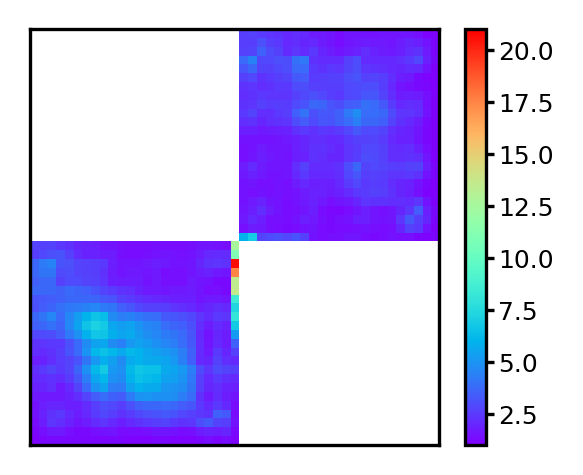

In [15]:
utils.use_pdf_plot()
plt.rcParams['xtick.bottom'] = plt.rcParams['xtick.labelbottom'] = False
plt.rcParams['ytick.left'] = plt.rcParams['ytick.labelleft'] = False
plt.rcParams['ytick.right'] = plt.rcParams['ytick.labelright'] = False

plt.subplots(figsize=(2.2, 1.8), dpi=300)
im = plt.imshow(rdiff_mat_LB.T, aspect='auto', cmap='rainbow')
plt.clim(1,21)
clb2 = plt.colorbar(im)
clb2.ax.set_title('')
# plt.savefig('Figures/SupFig/Granger stationary.pdf', format='pdf', dpi=300)

In [16]:
data = []
for probe in ['probeC','probeD']:
    channel_id = np.arange(cortex_channel[probe][0], cortex_channel[probe][1])
    temp = V1.lfp[probe].lfp[:,:,V1.running_trial_index]
    data.append( temp[channel_id,:,:] )
    print(len(channel_id))
data = np.concatenate(data, axis=0)
data = data[::1,:,:]

23
24


In [17]:
rdiff_mat_LB, rdiff_mat = granger(data, npadding=100, maxlag=5, out=None)
rdiff_mat_LB = make_diag_nan(rdiff_mat_LB, 24)

  0%|          | 0/47 [00:00<?, ?it/s]

/home/qix/anaconda3/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:1488: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
100%|██████████| 47/47 [02:53<00:00,  3.69s/it]


In [18]:
np.nanmax(rdiff_mat_LB), np.nanmin(rdiff_mat_LB)

(20.873498282072426, 0.7869091296596288)

Text(0.5, 1.0, '')

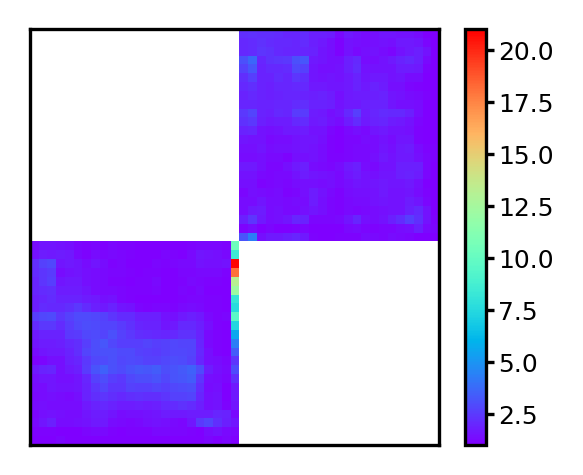

In [19]:
utils.use_pdf_plot()
plt.rcParams['xtick.bottom'] = plt.rcParams['xtick.labelbottom'] = False
plt.rcParams['ytick.left'] = plt.rcParams['ytick.labelleft'] = False
plt.rcParams['ytick.right'] = plt.rcParams['ytick.labelright'] = False

plt.subplots(figsize=(2.2, 1.8), dpi=300)
im = plt.imshow(rdiff_mat_LB.T, aspect='auto', cmap='rainbow')
plt.clim(1,21)
clb2 = plt.colorbar(im)
clb2.ax.set_title('')
# plt.savefig('Figures/SupFig/Granger running.pdf', format='pdf', dpi=300)